In [28]:
import re
import sys
import json
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from us import states
from census import Census

import useful
from setup import CENSUS_API_KEY

target_years = [2024]

variables: https://api.census.gov/data/2024/acs/acs5/variables.html

In [54]:
def _tract_econ_data(target_years, loud=False):

    prefixes = {
        "B25119_003": "med_inc", # median renter income "universe": "Occupied housing units"

        "B25003_003": "rent_occ", # "universe": "Occupied housing units"
        "B25069_002": "pay_util", # "universe": "Renter-occupied housing units"
        "B25069_003": "no_pay_util"

    }
    
    output = useful.tract_states_years_variables(
        useful.target_states, target_years, prefixes, 
        loud=loud)


    output['test'] = output['pay_util'] + output['no_pay_util'] - output['rent_occ']
    if set(output['test']) != {0}:
        sys.exit("Data error: rent_off != pay_util + no_pay_util.")
    output.drop(columns=['test'], inplace=True)
    
    output = useful.proportion(output, 'pct_pay_util', 'pay_util', 'rent_occ')


    # first_cols = ["year", "GEOID"]
    # last_cols = [col for col in output.columns if col not in first_cols]
    # output = output[first_cols + last_cols]

    return output


def _cousub_econ_data(target_years, loud=False):

    prefixes = {
        "B25119_003": "med_inc", # median renter income "universe": "Occupied housing units"

        "B25003_003": "rent_occ", # "universe": "Occupied housing units"
        "B25069_002": "pay_util", # "universe": "Renter-occupied housing units"
        "B25069_003": "no_pay_util"

    }
    
    output = useful.cousub_states_years_variables(
        useful.target_states, target_years, prefixes, 
        loud=loud)
    
    output['test'] = output['pay_util'] + output['no_pay_util'] - output['rent_occ']
    if set(output['test']) != {0}:
        sys.exit("Data error: rent_off != pay_util + no_pay_util.")
    output.drop(columns=['test'], inplace=True)
    
    output = useful.proportion(output, 'pct_pay_util', 'pay_util', 'rent_occ')


    # first_cols = ["year", "GEOID"]
    # last_cols = [col for col in output.columns if col not in first_cols]
    # output = output[first_cols + last_cols]

    return output


In [55]:
df = _tract_econ_data(target_years,loud=False)

In [41]:
cousub_gdf =  gpd.GeoDataFrame(
    pd.concat([
        gpd.read_file('./shapes/tl_2024_09_cousub'),
        gpd.read_file('./shapes/tl_2024_23_cousub'), 
        gpd.read_file('./shapes/tl_2024_25_cousub'),
        gpd.read_file('./shapes/tl_2024_33_cousub'),
        gpd.read_file('./shapes/tl_2024_44_cousub'),
        gpd.read_file('./shapes/tl_2024_50_cousub'),
    ])
).merge(
    _cousub_econ_data(target_years,loud=False), 
    on="GEOID", 
    how="inner"
).reset_index()

<Axes: >

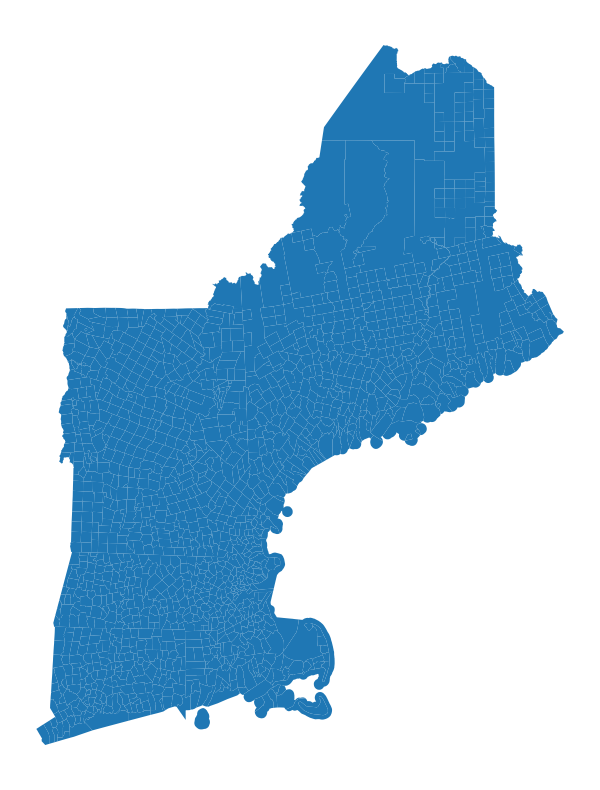

In [37]:
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

cousub_gdf.plot(ax=ax)